KeyboardInterrupt: 

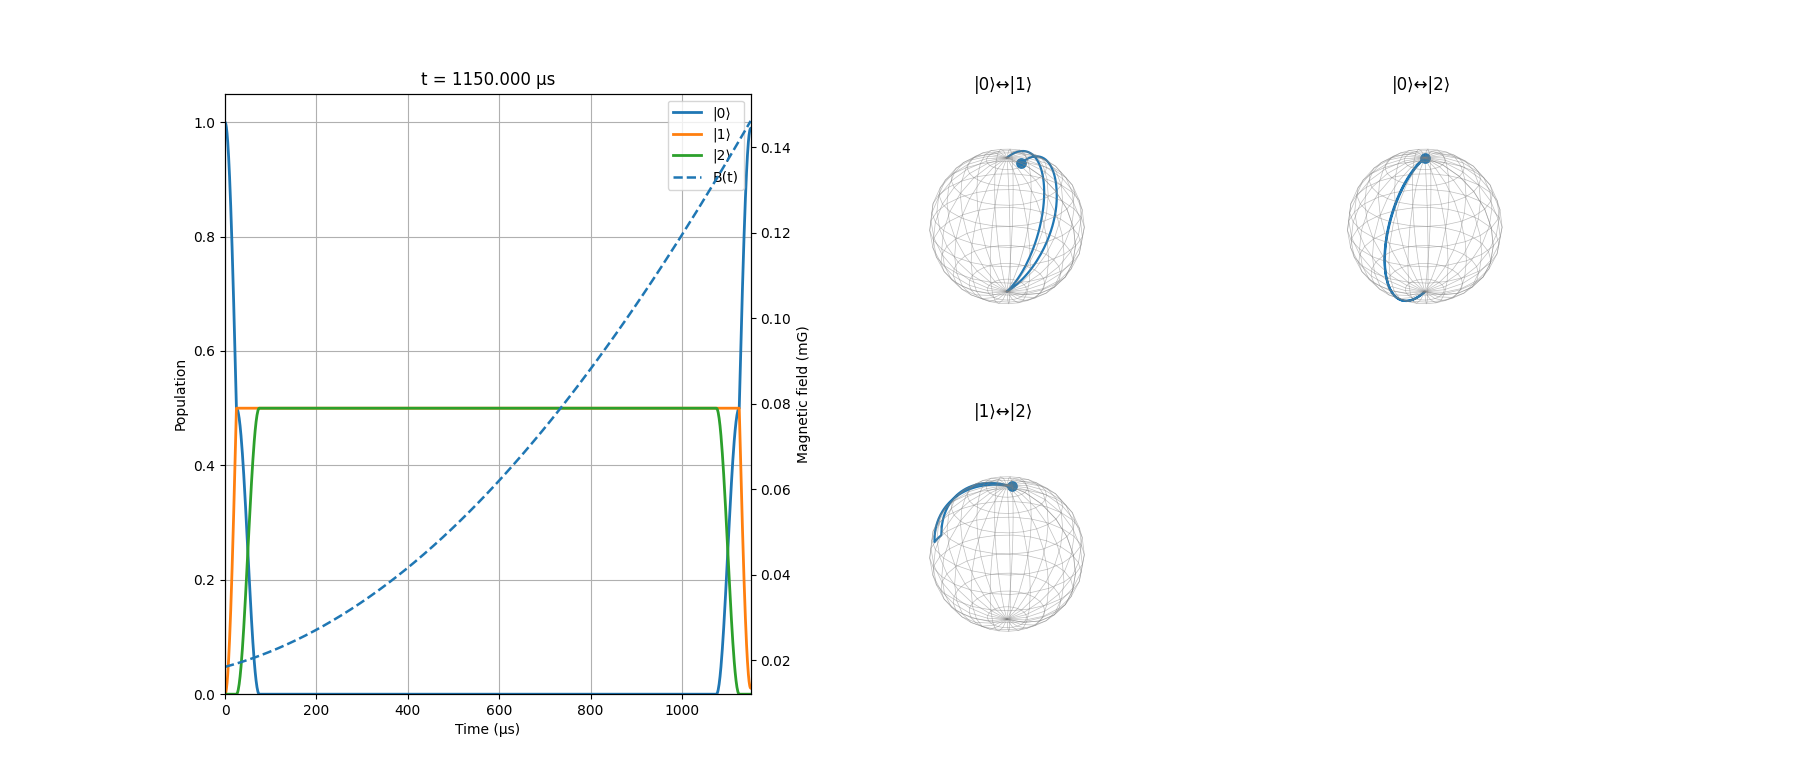

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from itertools import combinations
from matplotlib import animation

def pulse_hamiltonian(i, j, Omega_rad_s, phase_rad, Delta_rad_s, dim):
    H = np.zeros((dim, dim), dtype=complex)
    H[i, i] -= Delta_rad_s / 2.0
    H[j, j] += Delta_rad_s / 2.0
    hij = 0.5 * Omega_rad_s * np.exp(1j * phase_rad)
    H[i, j] += hij
    H[j, i] += np.conjugate(hij)
    return H

def evolve_time_dependent_H(psi, H_of_t, duration_s, n_steps, t_start_s):
    if duration_s <= 0:
        return np.array([0.0]), np.array([psi])
    n_steps = int(max(1, n_steps))
    dt = duration_s / n_steps
    times = np.full(n_steps, dt, dtype=float)
    states = np.empty((n_steps, psi.shape[0]), dtype=complex)
    v = psi.copy()
    for k in range(n_steps):
        t_mid = t_start_s + (k + 0.5) * dt
        H = H_of_t(t_mid)
        U = expm(-1j * H * dt)
        v = U @ v
        states[k] = v
    return times, states

def infer_state_shifts_from_transition_sens(dim, transition_sens_MHz_per_G, ref_state=0):
    shifts = np.zeros(dim, dtype=float)
    shifts[ref_state] = 0.0
    for k in range(dim):
        if k == ref_state:
            continue
        if (ref_state, k) in transition_sens_MHz_per_G:
            shifts[k] = transition_sens_MHz_per_G[(ref_state, k)]
        elif (k, ref_state) in transition_sens_MHz_per_G:
            shifts[k] = -transition_sens_MHz_per_G[(k, ref_state)]
        else:
            raise KeyError(f"Need transition_sens_MHz_per_G for ({ref_state},{k}) to infer state shifts.")
    return shifts

def simulate_n_level_with_B(
    pulse_train, fractions, phases,
    rabi_freqs_kHz, detunings_MHz,
    wait_time_s=0.0, wait_detunings_MHz=None,
    transition_sens_MHz_per_G=None,
    state_shifts_MHz_per_G=None,
    B_func=None, B_ref_G=0.0,
    psi0=None, steps_per_segment=200, dim=None
):
    if dim is None:
        dim = 3
    if psi0 is None:
        psi0 = np.zeros(dim, dtype=complex)
        psi0[0] = 1.0 + 0j
    psi = psi0.astype(complex)

    if B_func is None:
        B_func = lambda t_s: B_ref_G

    if state_shifts_MHz_per_G is None:
        if transition_sens_MHz_per_G is None:
            state_shifts_MHz_per_G = np.zeros(dim, dtype=float)
        else:
            state_shifts_MHz_per_G = infer_state_shifts_from_transition_sens(dim, transition_sens_MHz_per_G, ref_state=0)
    else:
        state_shifts_MHz_per_G = np.array(state_shifts_MHz_per_G, dtype=float)
        if state_shifts_MHz_per_G.shape != (dim,):
            raise ValueError("state_shifts_MHz_per_G must have length = dim")

    if wait_detunings_MHz is None:
        wait_detunings_MHz = np.zeros(dim, dtype=float)
    else:
        wait_detunings_MHz = np.array(wait_detunings_MHz, dtype=float)
        if wait_detunings_MHz.shape != (dim,):
            raise ValueError("wait_detunings_MHz must have length = dim")

    def get_key(a, b, d):
        if (a, b) in d:
            return (a, b), +1
        if (b, a) in d:
            return (b, a), -1
        raise KeyError((a, b))

    t0 = 0.0
    all_t = [t0]
    all_psi = [psi.copy()]

    for seg, frac, ph in zip(pulse_train, fractions, phases):
        if seg == "Wait":
            duration = float(wait_time_s)

            def H_of_t(t_s):
                B = B_func(t_s)
                dB = B - B_ref_G
                diag_MHz = wait_detunings_MHz + state_shifts_MHz_per_G * dB
                H = np.zeros((dim, dim), dtype=complex)
                for k in range(dim):
                    H[k, k] = 2*np.pi * diag_MHz[k] * 1e6
                return H

            dtimes, dstates = evolve_time_dependent_H(psi, H_of_t, duration, steps_per_segment, t0)

        else:
            i, j = seg
            key_r, _ = get_key(i, j, rabi_freqs_kHz)
            key_d, _ = get_key(i, j, detunings_MHz)

            Omega = 2*np.pi * rabi_freqs_kHz[key_r] * 1e3
            Delta0_MHz = detunings_MHz[key_d]
            duration = float(frac) * (np.pi / Omega)
            phase_rad = float(ph) * np.pi

            def H_of_t(t_s):
                B = B_func(t_s)
                dB = B - B_ref_G
                Delta_MHz = Delta0_MHz + (state_shifts_MHz_per_G[j] - state_shifts_MHz_per_G[i]) * dB
                Delta = 2*np.pi * Delta_MHz * 1e6
                return pulse_hamiltonian(i, j, Omega, phase_rad, Delta, dim)

            dtimes, dstates = evolve_time_dependent_H(psi, H_of_t, duration, steps_per_segment, t0)

        for dt, st in zip(dtimes, dstates):
            t0 += dt
            all_t.append(t0)
            all_psi.append(st.copy())
        psi = all_psi[-1].copy()

    return np.array(all_t), np.vstack(all_psi)

def bloch_from_states(states, i, j, eps=1e-12):
    a = states[:, i]
    b = states[:, j]
    p = (np.abs(a)**2 + np.abs(b)**2).real
    m = p > eps

    x = np.full(states.shape[0], np.nan, dtype=float)
    y = np.full(states.shape[0], np.nan, dtype=float)
    z = np.full(states.shape[0], np.nan, dtype=float)

    an = np.zeros_like(a)
    bn = np.zeros_like(b)
    an[m] = a[m] / np.sqrt(p[m])
    bn[m] = b[m] / np.sqrt(p[m])

    x[m] = 2 * np.real(an[m] * np.conj(bn[m]))
    y[m] = 2 * np.imag(an[m] * np.conj(bn[m]))
    z[m] = (np.abs(an[m])**2 - np.abs(bn[m])**2).real

    return x, y, z

def line_signal_model(t_us, B0, A60, phi60, A180, phi180):
    t_s = t_us * 1e-6
    return (
        B0
        + A60 * np.cos(2 * np.pi * 60 * t_s + phi60)
        + A180 * np.cos(2 * np.pi * 180 * t_s + phi180)
    )

def animate_populations_and_all_bloch_right_with_B(times_s, states, B_func, labels=None,
                                                   stride=4, interval=10,
                                                   sphere_points=26, ncols_right=2):

    times_s = times_s[::stride]
    states = states[::stride]

    d = states.shape[1]
    if labels is None:
        labels = [f"|{k}⟩" for k in range(d)]

    pairs = list(combinations(range(d), 2))
    n_bloch = len(pairs)

    Xs = {}
    Ys = {}
    Zs = {}
    for (i, j) in pairs:
        x, y, z = bloch_from_states(states, i, j)
        Xs[(i, j)] = x
        Ys[(i, j)] = y
        Zs[(i, j)] = z

    pops_all = np.abs(states)**2
    t_us = times_s / 1e-6
    B_mG = np.array([B_func(t) for t in times_s], dtype=float) * 1e3

    nrows_right = int(np.ceil(n_bloch / ncols_right))

    fig = plt.figure(figsize=(18, 7.8))
    gs = fig.add_gridspec(1, 2, width_ratios=[1.45, 2.25], wspace=0.08)

    ax_pop = fig.add_subplot(gs[0, 0])
    pop_lines = []
    for i in range(d):
        (ln,) = ax_pop.plot([], [], lw=2, label=labels[i])
        pop_lines.append(ln)
    ax_pop.set_xlim(t_us[0], t_us[-1])
    ax_pop.set_ylim(0, 1.05)
    ax_pop.set_xlabel("Time (µs)")
    ax_pop.set_ylabel("Population")
    ax_pop.grid(True)

    axB = ax_pop.twinx()
    (b_line,) = axB.plot([], [], linestyle="--", lw=1.8, label="B(t)")
    axB.set_ylabel("Magnetic field (mG)")
    axB.set_ylim(np.nanmin(B_mG) - 0.05 * np.ptp(B_mG), np.nanmax(B_mG) + 0.05 * np.ptp(B_mG))

    l1, lab1 = ax_pop.get_legend_handles_labels()
    l2, lab2 = axB.get_legend_handles_labels()
    ax_pop.legend(l1 + l2, lab1 + lab2, loc="upper right")

    gs_right = gs[0, 1].subgridspec(nrows_right, ncols_right, wspace=0.05, hspace=0.20)

    u = np.linspace(0, 2 * np.pi, sphere_points)
    v = np.linspace(0, np.pi, max(8, sphere_points // 2))
    xs = np.outer(np.cos(u), np.sin(v))
    ys = np.outer(np.sin(u), np.sin(v))
    zs = np.outer(np.ones_like(u), np.cos(v))

    bloch_pts = {}
    bloch_trajs = {}

    for idx, (i, j) in enumerate(pairs):
        r = idx // ncols_right
        c = idx % ncols_right
        ax = fig.add_subplot(gs_right[r, c], projection="3d")
        ax.plot_wireframe(xs, ys, zs, rstride=1, cstride=1, linewidth=0.5, alpha=0.50, color="gray")
        ax.set_xlim(-1.05, 1.05)
        ax.set_ylim(-1.05, 1.05)
        ax.set_zlim(-1.05, 1.05)
        ax.set_box_aspect((1, 1, 1))
        ax.set_title(f"{labels[i]}↔{labels[j]}", pad=2)
        ax.set_axis_off()
        pt = ax.scatter([0], [0], [1], s=45)
        (tr,) = ax.plot([], [], [], lw=1.6)
        bloch_pts[(i, j)] = pt
        bloch_trajs[(i, j)] = tr

    def update(frame):
        for i, ln in enumerate(pop_lines):
            ln.set_data(t_us[:frame+1], pops_all[:frame+1, i])
        b_line.set_data(t_us[:frame+1], B_mG[:frame+1])
        ax_pop.set_title(f"t = {t_us[frame]:.3f} µs")

        for (i, j) in pairs:
            x = Xs[(i, j)][frame]
            y = Ys[(i, j)][frame]
            z = Zs[(i, j)][frame]
            bloch_pts[(i, j)]._offsets3d = ([x], [y], [z])

            bloch_trajs[(i, j)].set_data(Xs[(i, j)][:frame+1], Ys[(i, j)][:frame+1])
            bloch_trajs[(i, j)].set_3d_properties(Zs[(i, j)][:frame+1])

        return list(pop_lines) + [b_line] + list(bloch_pts.values()) + list(bloch_trajs.values())

    ani = animation.FuncAnimation(fig, update, frames=len(times_s), interval=interval, blit=False)
    from matplotlib.animation import PillowWriter
    ani.save("three_level_bloch.gif", writer=PillowWriter(fps=30))
    plt.tight_layout()
    plt.show()
    return ani


if __name__ == "__main__":
    pulse_train = [(0, 1), (0, 2), "Wait", (0, 2), (0, 1)]
    fractions = [0.5, 1.0, "Wait", 1.0, 0.5]
    phases = [0.0, 1.0, "Wait", 0.0, 1.0]

    rabi_freqs_kHz = {(0, 1): 10.0, (0, 2): 10.0}
    detunings_MHz = {(0, 1): 0.0, (0, 2): 0.0}

    transition_sens_MHz_per_G = {(0, 1): -0.2, (0, 2): 0.3}

    B0_mG = 0.3076
    A60_mG = -0.2973
    phi60 = 0.8148
    A180_mG = -0.0969
    phi180 = -0.4964

    B_func = lambda t_s: line_signal_model(
        t_s / 1e-6,
        B0_mG, A60_mG, phi60, A180_mG, phi180
    ) * 1e-3

    wait_time_s = 1000e-6
    wait_detunings_MHz = [0.0, 0.0, 0.0]

    times, states = simulate_n_level_with_B(
        pulse_train, fractions, phases,
        rabi_freqs_kHz, detunings_MHz,
        wait_time_s=wait_time_s,
        wait_detunings_MHz=wait_detunings_MHz,
        transition_sens_MHz_per_G=transition_sens_MHz_per_G,
        state_shifts_MHz_per_G=None,
        B_func=B_func, B_ref_G=0.0,
        psi0=np.array([1.0 + 0j, 0.0 + 0j, 0.0 + 0j]),
        steps_per_segment=300,
        dim=3
    )

    animate_populations_and_all_bloch_right_with_B(
        times, states,
        B_func=B_func,
        labels=["|0⟩", "|1⟩", "|2⟩"],
        stride=6,
        interval=8,
        sphere_points=26,
        ncols_right=2
    )
